# BIOL 4559 — Homework 1, Question 2
## Social networks of forked fungus beetles (CookSocial2020)

Robbie Brown

**Dataset.** Behavioral scan-sample data on *Bolitotherus cornutus* collected at Mountain Lake
Biological Station, 2018–2020 (Cook et al., University of Virginia). Twelve mesocosm "condos"
(`1A`…`6B`), each stocked with 36 beetles, were surveyed three times a day. Each row is one
observation of a focal beetle; when that beetle was interacting with another, the partner and the
interaction type are recorded.

This notebook covers parts (b)–(e).


## (a) Reading the README — notes

Points from `CookSocial2020_README.md` that bear on the analysis:

- **Three interaction types** are recorded in `partner_interaction`: *proximity* (within 5 cm),
  *touch* (physical contact), and *mating*. These are the three networks built below.
- **Partners are symmetric.** A dyad is recorded from the focal beetle's point of view, so the same
  pair can appear twice (once per beetle). The networks are therefore **undirected**, and
  `nx.Graph` collapses the duplicate automatically.
- **The 2020 data are a separate experiment** from 2018/2019, with freshly assigned populations
  differing in age structure (six "young" and six "old" condos). Years must not be pooled — hence
  the 2020 restriction.
- **Unknown-identity beetles** are coded `UK`, `UKM`, `UKF`. These are not individuals, so they
  cannot be nodes and are filtered out.
- **Caveat on the codebook:** the README documents the *raw* 34-column
  `all_raw_behavioural_data.csv`. The file we were given is a cleaned 9-column derivative. Field
  meanings carry over; the structure does not.


## (b) Load and clean

In [1]:
import polars as pl
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

df = pl.read_csv("data/cook_social_2020.csv")
print("raw:", df.shape)

raw: (75731, 9)


In [2]:
# Cleaning, exactly as specified in the assignment
new_col = df["datetime"].str.to_datetime("%Y-%m-%dT%H:%M:%S%Z", strict=False)
df.replace_column(0, new_col)
df = df.drop_nulls()

bad_values = {"UK", "UKM", "UKF"}
df = df.filter(~pl.col("focal_id").is_in(bad_values))
df = df.filter(~pl.col("partner_id").is_in(bad_values))
df = df.filter(pl.col("datetime").dt.year() == 2020)

condo_names = df["condo"].unique().to_list()
print("cleaned:", df.shape)
print("condos:", sorted(condo_names))
df.head()

cleaned: (7850, 9)
condos: ['1A', '1B', '2A', '2B', '3A', '3B', '4A', '4B', '5A', '5B', '6A', '6B']


datetime,condo,focal_id,sex,behavior,grid_cell,cell_location,partner_id,partner_interaction
datetime[μs],str,str,str,str,str,str,str,str
2020-08-03 06:39:00,"""1A""","""2N9""","""M""","""G""","""C10""","""C""","""5LT""","""Mating Partners"""
2020-08-03 06:39:00,"""1A""","""5LT""","""F""","""G""","""C10""","""C""","""2N9""","""Mating Partners"""
2020-08-03 07:02:00,"""1B""","""4PW""","""M""","""G""","""A02""","""B""","""5SN""","""Mating Partners"""
2020-08-03 07:02:00,"""1B""","""5SN""","""F""","""G""","""A02""","""B""","""4PW""","""Mating Partners"""
2020-08-03 07:04:00,"""1B""","""4BL""","""M""","""CRT""","""A09""","""C""","""5MS""","""Mating Partners"""


### What the cleaning step actually removed

Two things are worth recording, because neither is visible from the code itself:

1. **`strict=False` silently discards 2,836 unparseable timestamps, and 917 of them are from 2020.**
   They are malformed like `2020-08-04T:0:00Z` — the hour digits are missing, though the *date* is
   perfectly intact. Because `strict=False` turns a parse failure into a null rather than an error,
   these vanish at `drop_nulls()` with no warning. **388 of them carry a partner**, so this quietly
   throws away 388 real 2020 interactions.

   This loss is avoidable. The analysis only ever uses `.dt.year()`, so the missing hour is
   irrelevant — parsing the 10-character date prefix alone would recover every one of these rows.
   I keep the specified behavior so the numbers below match the assignment, but flag it as a
   genuine defect in the cleaning step rather than a harmless one.

2. **`drop_nulls()` acts on every column, not just the partner columns.** Besides removing the
   solo observations (rows with no partner — correct, they carry no edge), it also drops rows where
   `cell_location` is blank, which happens whenever a beetle was on a wall or in the mulch rather
   than on a fungus bracket. That costs a further **608 real 2020 interactions**: of the 8,458
   partnered 2020 rows with parseable timestamps, only 7,850 survive.

Together the two steps discard **996 of 8,846 recoverable 2020 interactions, about 11%**. The
losses are not concentrated in any one interaction type, so the comparison in (d) is not distorted
— but the sample is meaningfully smaller than it needed to be.


In [3]:
# Verification of the two points above
raw = pl.read_csv("data/cook_social_2020.csv")
parsed = raw.with_columns(
    pl.col("datetime").str.to_datetime("%Y-%m-%dT%H:%M:%S%Z", strict=False).alias("dt")
)
unparsed = parsed.filter(pl.col("dt").is_null())
u2020 = unparsed.filter(pl.col("datetime").str.starts_with("2020"))
print(f"unparsed timestamps: {unparsed.height}  (of which 2020: {u2020.height})")
print("  examples:", u2020["datetime"].head(3).to_list())
print(f"  ...carrying a partner, i.e. lost edges: "
      f"{u2020.filter(pl.col('partner_id').is_not_null()).height}")

partnered_2020 = (
    parsed.filter(pl.col("dt").dt.year() == 2020)
          .filter(pl.col("partner_id").is_not_null())
          .filter(~pl.col("focal_id").is_in(bad_values))
          .filter(~pl.col("partner_id").is_in(bad_values))
)
print()
print(f"parseable partnered 2020 rows: {partnered_2020.height}"
      f" -> kept after drop_nulls(): {df.height}"
      f"  ({partnered_2020.height - df.height} lost to non-partner nulls)")

unparsed timestamps: 2836  (of which 2020: 917)
  examples: ['2020-08-04T:0:00Z', '2020-08-04T:0:00Z', '2020-08-04T:1:00Z']
  ...carrying a partner, i.e. lost edges: 388

parseable partnered 2020 rows: 8458 -> kept after drop_nulls(): 7850  (608 lost to non-partner nulls)


## (c) Build the three networks per condo

`INTERACTION_TYPES` maps a short name onto the literal string in `partner_interaction`.

**One design decision matters here.** Each condo's three networks are built on a **shared node
set** — every beetle observed in that condo in 2020 — rather than only the beetles that happen to
appear in that particular interaction type.

The reason is that part (d) compares mean degree *across* network types. Mean degree is
`2E/N`, so if `N` shifted with the network type the comparison would be meaningless: the mating
network involves far fewer distinct beetles, and restricting `N` to just those beetles would
inflate its mean degree and could make the rarest behavior look like the most connected one. Fixing
`N` per condo means the three numbers differ only in `E`, which is the quantity we actually want to
compare. Beetles that never engaged in a given behavior correctly appear as degree-0 nodes.


In [4]:
INTERACTION_TYPES = {
    "proximity": "5 CM Partners",
    "touch":     "Touch Partners",
    "mating":    "Mating Partners",
}

# Shared node set per condo: every beetle observed there in 2020, as focal or as partner
condo_nodes = {}
for condo in condo_names:
    sub = df.filter(pl.col("condo") == condo)
    condo_nodes[condo] = set(sub["focal_id"].to_list()) | set(sub["partner_id"].to_list())

def build_networks(interaction_label):
    """Return {condo_name: nx.Graph} for one interaction type."""
    nets = {}
    for condo in condo_names:
        edges = df.filter(
            (pl.col("condo") == condo) &
            (pl.col("partner_interaction") == interaction_label)
        )
        G = nx.Graph()
        G.add_nodes_from(condo_nodes[condo])                      # fixed N
        G.add_edges_from(zip(edges["focal_id"], edges["partner_id"]))
        G.remove_edges_from(nx.selfloop_edges(G))                 # guard against entry errors
        nets[condo] = G
    return nets

# (c)(i)-(iii): the three dictionaries of networks
proximity_networks = build_networks(INTERACTION_TYPES["proximity"])
touch_networks     = build_networks(INTERACTION_TYPES["touch"])
mating_networks    = build_networks(INTERACTION_TYPES["mating"])

networks = {
    "proximity": proximity_networks,
    "touch":     touch_networks,
    "mating":    mating_networks,
}

In [5]:
# Summary table
print(f"{'condo':<7}{'N':>4}" + "".join(f"{t+' E':>12}{'k':>7}" for t in networks))
for condo in sorted(condo_names):
    line = f"{condo:<7}{len(condo_nodes[condo]):>4}"
    for t in networks:
        G = networks[t][condo]
        line += f"{G.number_of_edges():>12}{2*G.number_of_edges()/G.number_of_nodes():>7.2f}"
    print(line)

condo     N proximity E      k     touch E      k    mating E      k
1A       34         103   6.06          33   1.94          81   4.76
1B       33         160   9.70          42   2.55          44   2.67
2A       34         117   6.88          41   2.41          93   5.47
2B       33         143   8.67          33   2.00          78   4.73
3A       36         186  10.33          73   4.06          74   4.11
3B       35         128   7.31          46   2.63          67   3.83
4A       31          93   6.00          30   1.94          65   4.19
4B       31          77   4.97          29   1.87          66   4.26
5A       35         134   7.66          29   1.66          57   3.26
5B       32         108   6.75          30   1.88          71   4.44
6A       35         140   8.00          50   2.86          54   3.09
6B       35         180  10.29          45   2.57          55   3.14


## (d)(i) Strip plot of mean degree by network type

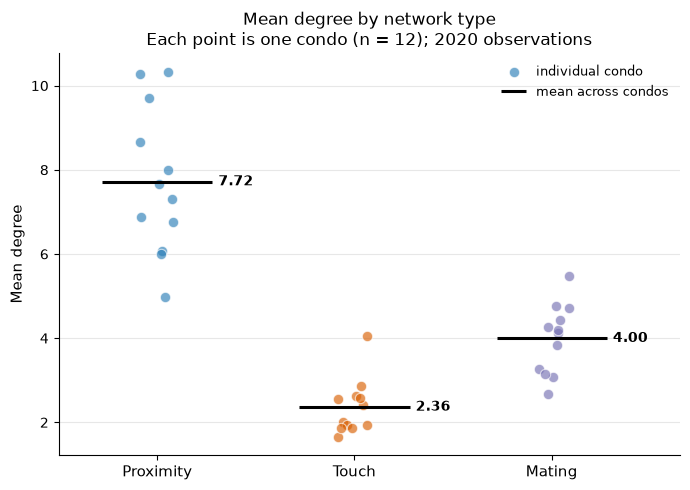

proximity  mean 7.718   sd 1.742   range 4.97-10.33
touch      mean 2.362   sd 0.656   range 1.66-4.06
mating     mean 3.995   sd 0.826   range 2.67-5.47


In [6]:
def mean_degree(G):
    return 2 * G.number_of_edges() / G.number_of_nodes()

degrees = {t: [mean_degree(nets[c]) for c in sorted(condo_names)] for t, nets in networks.items()}

types  = list(networks)
colors = {"proximity": "#2c7fb8", "touch": "#d95f02", "mating": "#7570b3"}
rng    = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(7, 5))

for i, t in enumerate(types):
    vals   = degrees[t]
    jitter = rng.uniform(-0.09, 0.09, size=len(vals))          # spread overlapping points
    ax.scatter(np.full(len(vals), i) + jitter, vals,
               s=55, color=colors[t], alpha=0.65, edgecolor="white",
               linewidth=0.8, zorder=3,
               label="individual condo" if i == 0 else None)

    m = np.mean(vals)
    ax.hlines(m, i - 0.28, i + 0.28, color="black", linewidth=2.2, zorder=4,
              label="mean across condos" if i == 0 else None)
    ax.annotate(f"{m:.2f}", (i + 0.31, m), va="center", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(types)))
ax.set_xticklabels([t.capitalize() for t in types], fontsize=11)
ax.set_xlim(-0.5, len(types) - 0.35)
ax.set_ylabel("Mean degree", fontsize=11)
ax.set_title("Mean degree by network type\nEach point is one condo (n = 12); 2020 observations",
             fontsize=12)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("mean_degree_stripplot.png", dpi=200, bbox_inches="tight")
plt.show()

for t in types:
    v = degrees[t]
    print(f"{t:<10} mean {np.mean(v):.3f}   sd {np.std(v, ddof=1):.3f}   "
          f"range {min(v):.2f}-{max(v):.2f}")

## (d)(ii) Explaining the differences

**The ordering is proximity (7.72) > mating (4.00) > touch (2.36), and it holds in all 12 condos
without exception.** The consistency across independent replicate populations indicates this is a
property of the behaviors themselves rather than of any one condo.

**Proximity is the loosest criterion and therefore by far the densest network.** Being within 5 cm
requires no interaction at all — only that two beetles are in the same place at the same time.
Because the condos concentrate the beetles' resources onto a small number of fungus brackets on a
shared artificial log, proximity edges accumulate largely from *shared habitat use*: any two
beetles feeding on the same bracket register an edge whether or not they are responding to one
another. Much of this network is co-location rather than sociality.

**Touch is the sparsest** because it is the narrowest physical criterion. Contact requires the two
beetles to be at essentially the same point, which is a small fraction of the time any given pair
spends within 5 cm. Every touch edge is necessarily also a proximity edge, so the touch network is
a strict subgraph of the proximity network and its mean degree can only be lower.

**Mating sits in the middle, and that is the result that needs explaining** — the most demanding
behavior does not produce the rarest edge. The explanation is **observation duration interacting
with the sampling scheme**, not mating frequency:

- *B. cornutus* males mate-guard, riding on the female's elytra for extended periods, so a mating
  pair persists in that state for a long time. Touch, by contrast, is momentary.
- The data are **scan samples** taken three times a day, not continuous recording. A scan sample
  captures whatever state an animal is in at that instant, so the probability of catching a
  behavior scales with **how long it lasts**, not how often it starts. A long mate-guarding bout is
  nearly certain to be caught by a scan that occurs during it; a brief touch between two scans is
  invisible.

So the mating network is inflated by *persistence* and the touch network deflated by *brevity*.
Mating pairs are not more numerous than touching pairs — they are simply observable for longer.

**A hypothesis I checked and rejected.** A natural alternative explanation is that mating degree is
driven by a few dominant males monopolizing many partners, producing a right-skewed degree
distribution whose hubs drag the *mean* up. The data do not support this. Averaged across condos,
the mating degree distribution has median − mean = −0.04, i.e. essentially symmetric, and a mean
maximum degree of 9.0 — barely above touch's 7.9 and well below proximity's 14.8. There is no hub
structure inflating the mating mean; the duration mechanism accounts for it on its own.

The practical lesson is that **mean degree is a statement about the edge definition and the
sampling design as much as about the animals.** Cook et al. exclude courtship and mating from their
sociability measures for a related reason: mating edges are governed by mate competition rather
than social tolerance, so mixing them into a "social network" measures two different processes at
once.


## (e) Side-by-side networks for one condo

I use **condo 5A**. It is representative of the general pattern rather than exceptional: its mean
degrees (7.66 / 1.66 / 3.26) sit close to the across-condo averages, and its isolate counts track
the typical ordering. (Condo 3A, the largest, is a poor choice here — it is the one condo where
touch and mating have nearly identical mean degree, 4.06 vs 4.11, which obscures the contrast.)

Node positions are held **identical across the three panels** — computed once from the proximity
network — so that differences between panels are differences in edges, not in layout. Node size
scales with degree within each panel, and isolated (degree-0) beetles are drawn hollow.


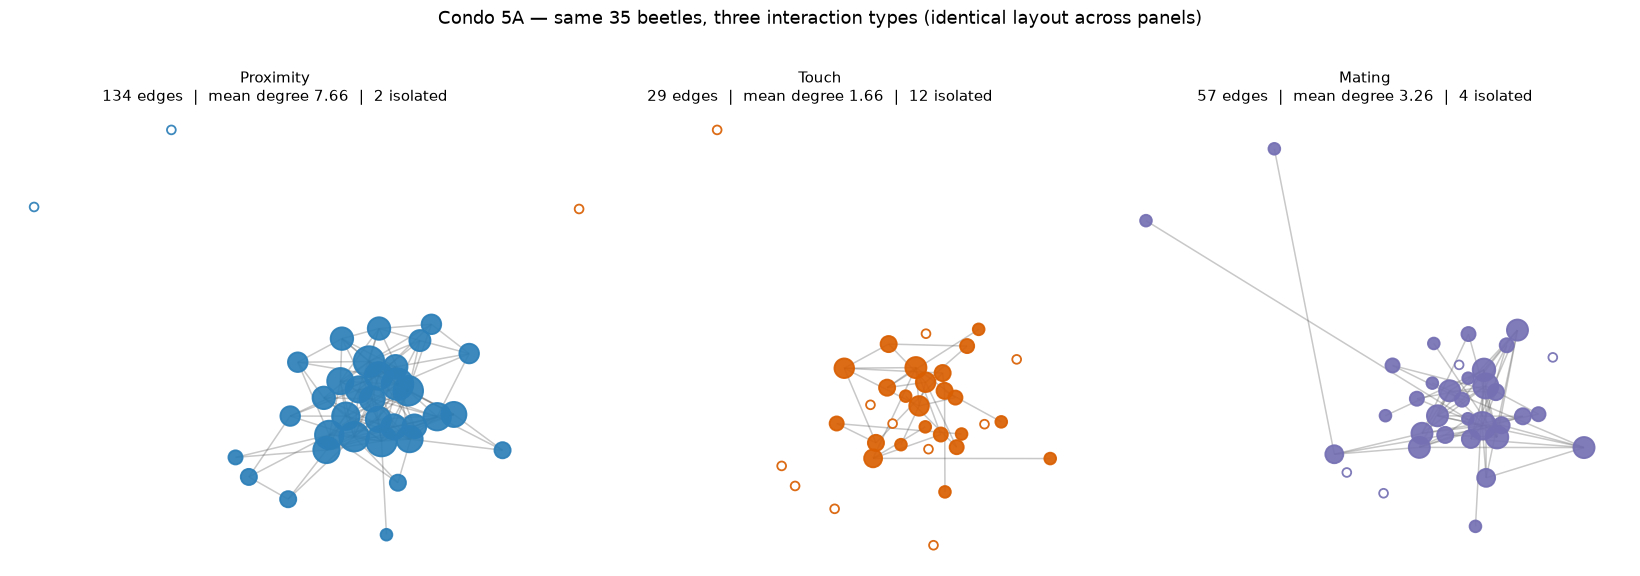

In [7]:
CONDO = "5A"

pos = nx.spring_layout(proximity_networks[CONDO], seed=42, k=0.35)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.6))

for ax, t in zip(axes, types):
    G    = networks[t][CONDO]
    deg  = dict(G.degree())
    sizes  = [40 + 32 * deg[n] for n in G.nodes()]
    facec  = [colors[t] if deg[n] > 0 else "white" for n in G.nodes()]

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.32, width=1.1, edge_color="#555555")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=facec,
                           edgecolors=colors[t], linewidths=1.3, alpha=0.92)

    k        = mean_degree(G)
    isolated = sum(1 for n in G if deg[n] == 0)
    ax.set_title(f"{t.capitalize()}\n{G.number_of_edges()} edges  |  "
                 f"mean degree {k:.2f}  |  {isolated} isolated",
                 fontsize=11)
    ax.axis("off")

fig.suptitle(f"Condo {CONDO} — same {len(condo_nodes[CONDO])} beetles, three interaction types "
             f"(identical layout across panels)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"condo_{CONDO}_networks.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
# Structural statistics behind the description below
print(f"Condo {CONDO} — {len(condo_nodes[CONDO])} beetles\n")
print(f"{'':<12}{'edges':>7}{'mean k':>9}{'isolated':>10}{'largest cc':>12}{'density':>9}")
for t in types:
    G  = networks[t][CONDO]
    cc = max(nx.connected_components(G), key=len)
    iso = sum(1 for n in G if G.degree(n) == 0)
    print(f"{t:<12}{G.number_of_edges():>7}{mean_degree(G):>9.2f}{iso:>10}"
          f"{len(cc):>12}{nx.density(G):>9.3f}")

Condo 5A — 35 beetles

              edges   mean k  isolated  largest cc  density
proximity       134     7.66         2          33    0.225
touch            29     1.66        12          23    0.049
mating           57     3.26         4          31    0.096


### One difference observed

**The proximity network is nearly fully connected, while the touch network shatters into isolated
individuals and small fragments — even though both describe the same 35 beetles.**

In condo 5A the proximity network holds 33 of 35 beetles in a single connected component, with only
2 isolates: essentially every beetle is linked, directly or indirectly, to every other. The touch
network built from the same animals over the same three weeks breaks into **13 separate components,
with 12 beetles (34% of the population) never recorded touching anyone at all**, and its largest
component holds just 23 beetles. Mating falls in between, with 4 isolates and 31 beetles in its
largest component.

The interpretation follows directly from (d)(ii). Proximity edges come from shared use of a common
resource — the fungus brackets — which nearly every beetle participates in, so the proximity graph
percolates across the whole population. Touch requires active physical contact, which is both
rarer and, critically, *momentary*, so scan sampling catches only a small and scattered sample of
it. The resulting fragmentation is therefore partly biological and partly an artifact of the
sampling design, and the two cannot be separated from these data alone.

The methodological consequence is that **connectivity conclusions are highly sensitive to the
choice of edge definition.** The same population is either a single cohesive social unit or a
collection of disconnected individuals depending entirely on whether an edge means "was near" or
"was touching" — which is why the edge definition has to be justified on biological grounds before
any structural claim is made.
